# 5) Constraining ERT with GPR reflections

Next, we want to take a look at pyGIMLIs capcabilities to include prior structural constraints into an inversion.

For this purpose, we want utilize a filtered GPR radargram acquired along the same profile transect as the ERT and SRT data used during the workshop. We start by loading and visualizing the GPR data, before actually implementing structural constraints into the ERT inversion. 

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import reflector_picker as rp
from pygimli.physics import ert
import pygimli.meshtools as mt

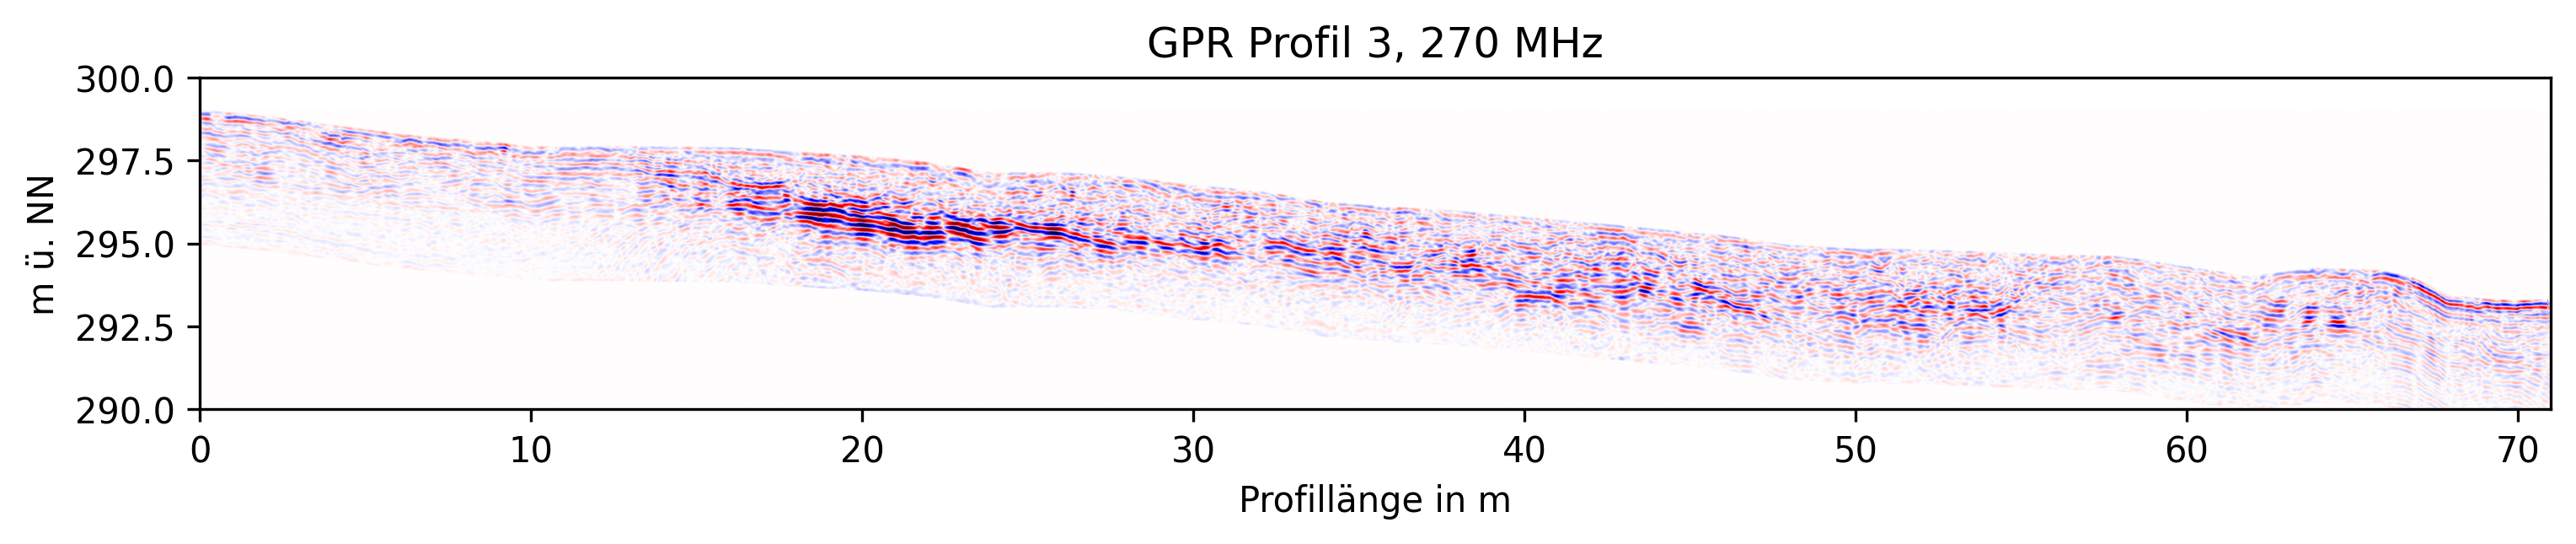

In [10]:
gpr = (np.loadtxt("../data/Profile_P2_270MHZ.ASC")).T
extent = [0,71,289.2,299.01]

fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=300, sharex=True, gridspec_kw={'hspace': .2})

im = ax.imshow(gpr,cmap='seismic', extent=extent)
ax.set_ylabel("m ü. NN")
ax.set_xlabel("Profillänge in m")
ax.set_title("GPR Profil 3, 270 MHz")
ax.set_ylim(290, 300)
ax.set_aspect("equal")

We can clearly see a reflection along a large section of the GPR transect, meaning that structural information can be extracted from the radargram. We will extract the information using a manual picking tool:

In [16]:
rp.digitize_reflector(gpr, extent, output_file="../data/reflector_GPR.txt", cmap="seismic")

In [17]:
reflector = np.loadtxt("../data/reflector_GPR.txt", skiprows=1)
print(reflector)

[[ 14.85131  296.308541]
 [ 16.103831 296.308541]
 [ 17.296707 296.069966]
 [ 18.191364 295.950678]
 [ 19.145665 295.771746]
 [ 20.15961  295.592815]
 [ 20.93498  295.533171]
 [ 21.889281 295.35424 ]
 [ 22.783938 295.35424 ]
 [ 23.559308 295.35424 ]
 [ 24.513609 295.35424 ]
 [ 25.288978 295.294596]
 [ 26.064348 295.234952]
 [ 27.197581 295.056021]
 [ 28.330813 294.996377]
 [ 29.22547  294.996377]
 [ 30.299059 294.817445]
 [ 31.313004 294.817445]
 [ 32.207661 294.757802]
 [ 33.221606 294.698158]
 [ 34.295195 294.57887 ]
 [ 35.368784 294.459582]
 [ 36.502016 294.221007]
 [ 37.217742 294.221007]
 [ 38.172043 294.10172 ]
 [ 39.185988 293.922788]
 [ 39.961358 293.743857]
 [ 40.796371 293.564925]]


Next up, we load the filtered ERT data file and create a mesh with our additional constraint layer: 

16/09/26 - 10:44:31 - pyGIMLi - INFO - Found 2 regions.
16/09/26 - 10:44:31 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

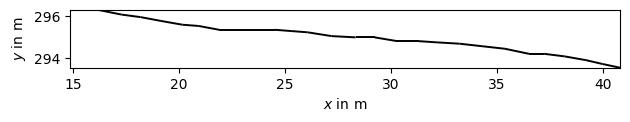

In [25]:
data = pg.load("../data/ERT_DD_filtered.dat")

mgr = ert.ERTManager(data)
plc = mt.createParaMeshPLC(data.sensorPositions(), paraDX=0.33, paraDepth=20, paraMaxCellSize=0.75)
line = mt.createPolygon(reflector, marker=1)
plc += line
mesh = mt.createMesh(plc)
mgr.setMesh(mesh)
pg.show(line)

On the mesh, it looks like this:

Text(0.5, 0, 'Profile length (m)')

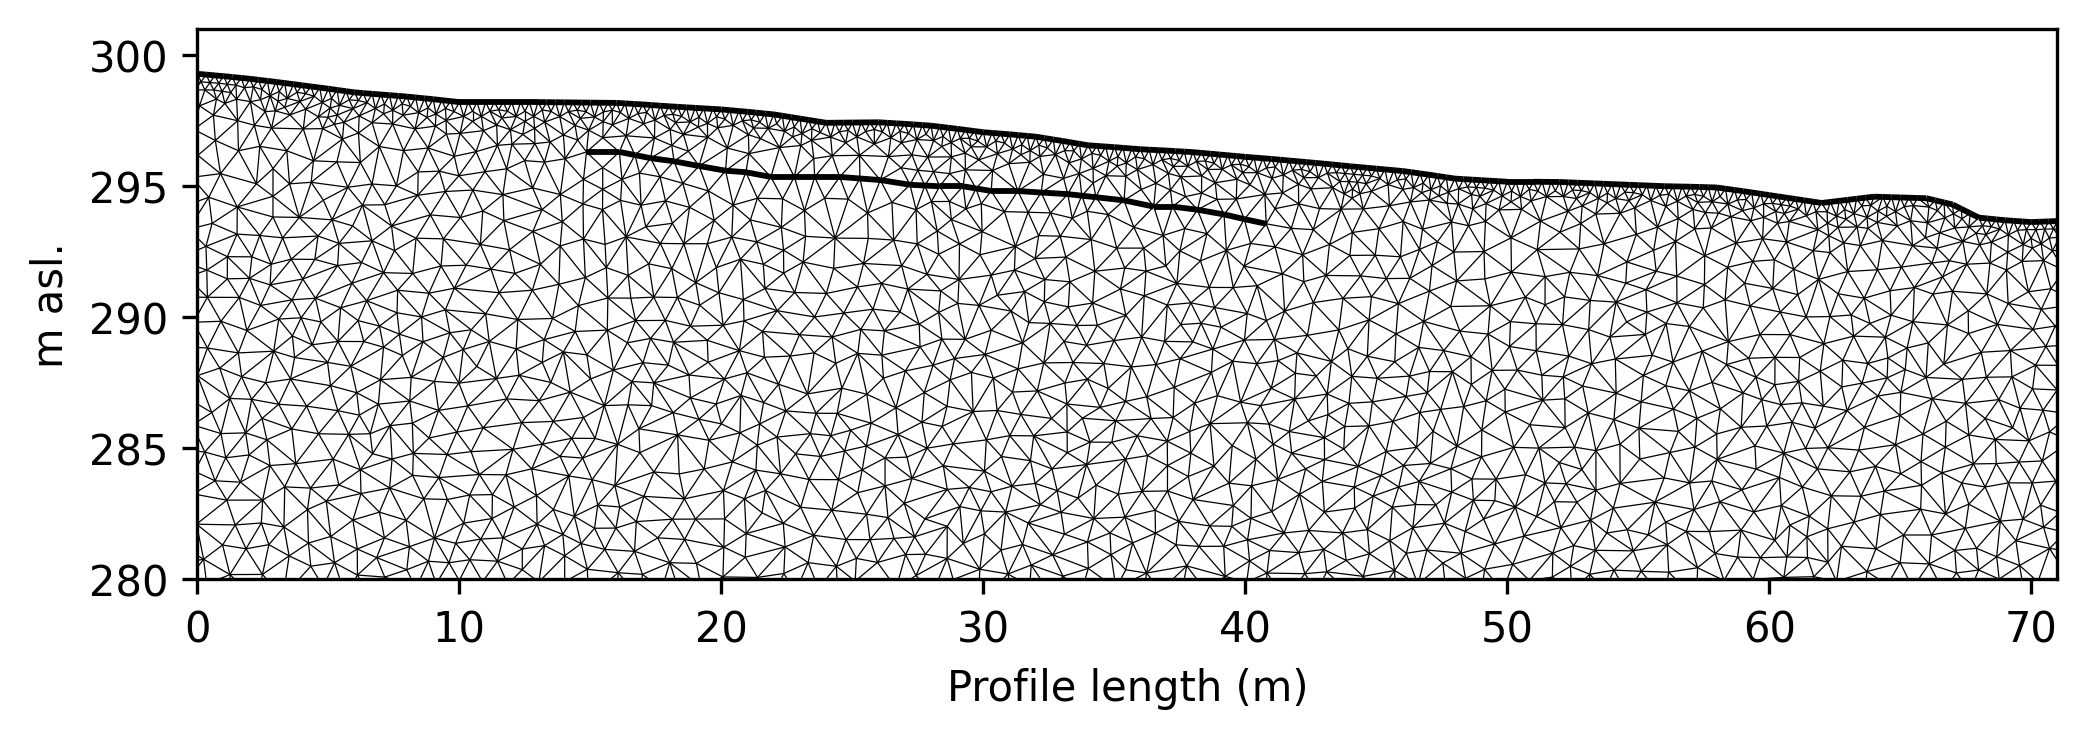

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=300, sharex=True, gridspec_kw={'hspace': .1})

pg.show(mesh, ax=ax)
ax.set_ylim(280, 301)
ax.set_xlim(0, 71)

ax.set_ylabel("m asl.")
ax.set_xlabel("Profile length (m)")

Now, we can simply run the inversion as we did for the simple ERT case. 

All the necessary information about the structural constraint are included in the mesh, so we do not need to set any additional parameters for the inversion.

In [26]:
invArgs = dict(mesh=mesh, lam = 45, verbose=True)

mgr = ert.ERTManager(data)
inv = mgr.invert(**invArgs)

16/09/26 - 10:45:17 - pyGIMLi - INFO - Found 2 regions.
16/09/26 - 10:45:17 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
16/09/26 - 10:45:17 - pyGIMLi - INFO - Creating forward mesh from region infos.
16/09/26 - 10:45:17 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
16/09/26 - 10:45:17 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11256 Cells: 21996 Boundaries: 16754
16/09/26 - 10:45:18 - pyGIMLi - INFO - Use median(data values)=144.315107136596
16/09/26 - 10:45:18 - pyGIMLi - INFO - Created startmodel from forward operator:4594, min/max=144.315107/144.315107
16/09/26 - 10:45:18 - pyGIMLi - INFO - Starting inversion.
16/09/26 - 10:45:18 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001B2D21EA6B0>
16/09/26 - 10:45:18 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
16/09/26 - 10:45:18 - pyGIMLi - INFO - Model transformation: Logarithmic

--------------------------------------------------------------------------------


16/09/26 - 10:45:51 - pyGIMLi - INFO - inv.iter 0 ... chi² =  413.32


--------------------------------------------------------------------------------
inv.iter 1 ... 

16/09/26 - 10:46:01 - pyGIMLi - INFO - chi² =   86.12 (dPhi = 78.89%) lam: 45.0


...

--------------------------------------------------------------------------------
inv.iter 4 ... 

16/09/26 - 10:46:53 - pyGIMLi - INFO - chi² =    1.04 (dPhi = 5.31%) lam: 45.0


--------------------------------------------------------------------------------
inv.iter 5 ... 

16/09/26 - 10:47:12 - pyGIMLi - INFO - chi² =    1.01 (dPhi = 0.99%) lam: 45.0


################################################################################
#                Abort criterion reached: dPhi = 0.99 (< 2.0%)                 #
################################################################################


Next up, let's compare the standard smoothness-constrained ERT inversion with the structurally-constrained inversion:

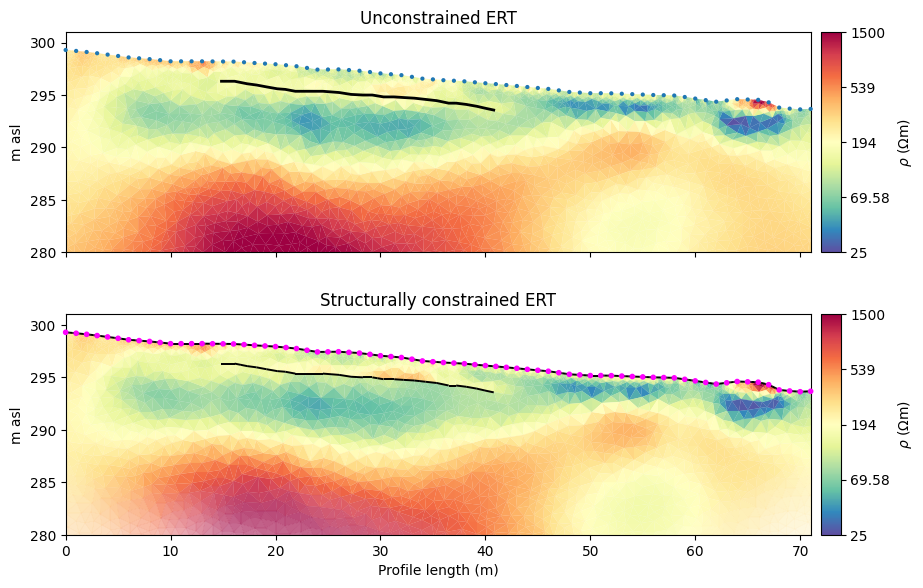

In [35]:
smooth_ERT = pg.load("../data/inv_ERT.vtk")

rKW = dict(logScale=True, cMin=25, cMax=1500, cMap="Spectral_r",
           orientation="vertical", label = r"$\rho$ ($\Omega$m)")

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10, 7),sharex=True, gridspec_kw={'hspace': .1})

pg.show(smooth_ERT, smooth_ERT["Resistivity"], ax=ax1, **rKW)
pg.viewer.mpl.drawSensors(ax1, data.sensors())
ax1.set_ylim(280, 301)
ax1.plot(reflector[:, 0], reflector[:, 1], color="black", linewidth=2)
ax1.set_xlim(0, 71)
ax1.set_ylabel("m asl")
ax1.set_title("Unconstrained ERT")
ax1.set_xlabel("")
ax1.set_aspect("equal")


mgr.showResult(ax=ax2, **rKW)
ax2.set_ylim(280, 301)
ax2.set_xlim(0, 71)
ax2.set_ylabel("m asl")
ax2.set_xlabel("Profile length (m)")
ax2.set_title("Structurally constrained ERT")
ax2.set_aspect("equal")

As we can see, due to the small extent of the reflector, the effect on the ERT model is also limited.

Nevertheless, we can see that it affects the upper layer boundary separating a moderately resistive near-surface layer from a more conductive lower zone.

As both GPR and ERT are sensitive to this particular change and the site shows very shallow groundwater-saturated sediments, this particular boundary could signalize the transition from dry to (partially) saturated sediments.